In [50]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D


In [51]:
# Constants
N = 32 # Number of points 
m = 1 # mass of each point
alpha = 0.25 # constant

dt = 0.01 # time step 
# NT = int(30000/dt) # Number of Time Step
time = np.arange(0, 30000, dt)
print(len(time))
A = 1.0 # Constant

# Definint Arrays for time, Position in y-axis(q), velocity(vel), & Acce;eration(acc).

q = np.zeros([N + 2])
j_ = np.arange(1, N + 1)
vel = np.zeros([N + 2])
# acc_t = np.zeros([N + 2])


q[1:N + 1] = A * np.sin((np.pi * j_) / (N + 1))
q_prev = q.copy()

# N = len(q)

TE_arr = []
C_time = []
ET1, ET2, ET3 = [], [], []
print(len(q))

3000000
34


In [52]:
# Defining a linear combination of normal modes 

phi = np.array([[np.sqrt(2 / (N + 1)) * np.sin((np.pi * k * j) / (N + 1)) 
                for k in range(1, N + 1)] for j in range(1, N+1)])  
print((phi.shape))

w = np.array([0] + [2 * np.sin((np.pi * k) / (2 * (N + 1))) 
                   for k in range(1, N+1)])
print(len(w))

def acc(q):
    prev_q = q[:-2]
    now_q = q[1:-1]
    next_q = q[2:]
    A_ = np.zeros_like(q)
    a_ = (next_q - 2 * now_q + prev_q) + alpha * ((next_q - now_q)**2 - (now_q - prev_q)**2)
    A_[1:-1] = a_
    return A_

(32, 32)
33


In [53]:
# Defining basis functions - Q and P
def QPE(q, P, Qt, Pt):
    E_tot = []
    Qt.clear()
    Pt.clear()
    for k in range(1, N + 1):
        Q_ = 0
        p_ = 0 
        for j in range(1, N + 1):
            Q_ += phi[j-1, k-1] * q[j]
            p_ += phi[j-1, k-1] * P[j]

        E_k = 0.5 * (p_**2 + w[k]**2 * Q_**2)
        E_tot.append(float(E_k))
        Qt.append(Q_)
        Pt.append(p_)
    return E_tot
# x = QPE(q, vel)
# print(x)

In [54]:
p_acc = acc(q)

Q0 = []
P0 = []
QPE(q, vel, Q0, P0)

R_time = []
RK_time = []
norm_E = []
print(len(C_time))

for i, t in enumerate(time):
    q += vel * dt + 0.5 * p_acc * dt * dt
    n_acc = acc(q)
    vel += 0.5 * dt * (p_acc + n_acc)
    p_acc = n_acc

    if i % 100 == 0:
        C_time.append(t)
        Q1, P1 = [], []
        
        
        Ek = QPE(q, vel, Q1, P1)

        norm_E_ = Ek / np.sum(Ek)

        RKT = []
        nume, deno = 0.0, 0.0
        for k in range(len(Q1)):  # Loop through each element
            nume += Q1[k] * Q0[k] + P1[k] * P0[k]
            deno += Q0[k] * Q0[k] + P0[k] * P0[k]
            RKT.append(nume/deno) 

        RK_time.append(RKT)

        R_time.append(nume/deno)

        ET1.append(Ek[0])
        ET2.append(Ek[1])
        ET3.append(Ek[2]) 

        norm_E.append(norm_E_)
        
        TE_arr.append(np.sum(Ek))  

0


34


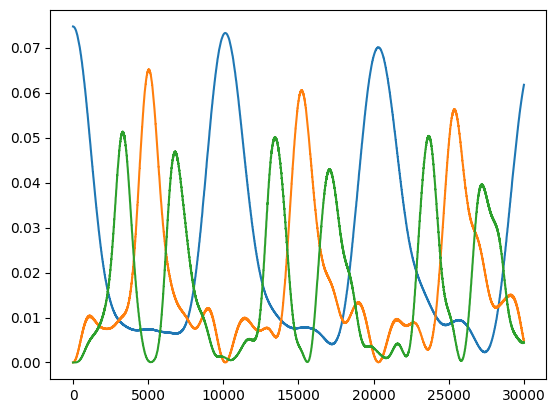

In [55]:
# plt.plot(range(len(q)),q, 'o-')

plt.plot(C_time, ET1, label = "Energy of mode 1")
plt.plot(C_time, ET2, label = "Energy of mode 2")
plt.plot(C_time, ET3, label = "Energy of mode 3")

# plt.legend()

print(len(q))

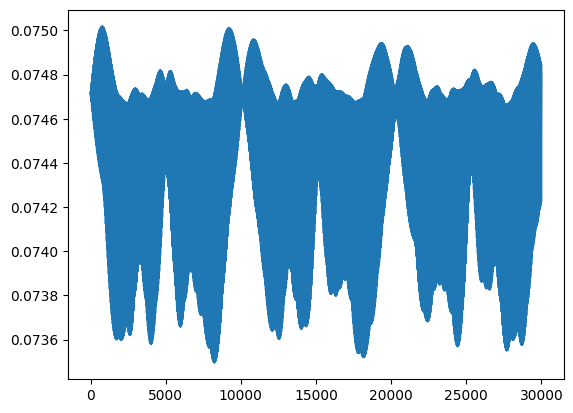

In [ ]:
plt.plot(C_time, TE_arr)

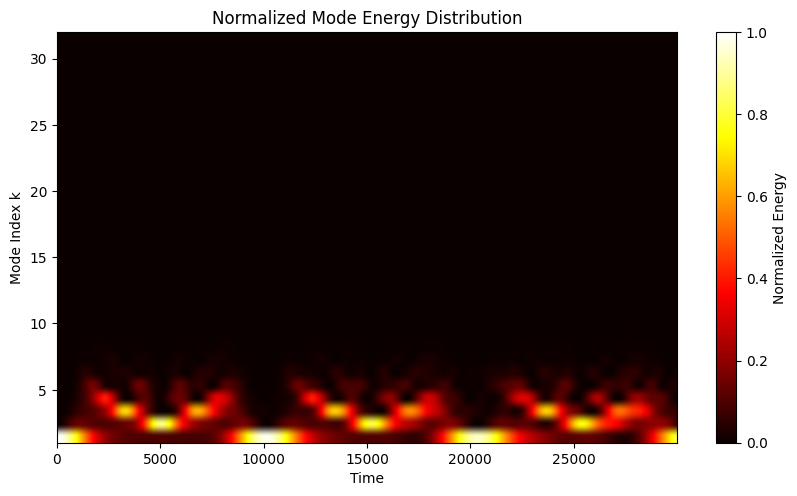

In [57]:
normalized_data = np.array(norm_E)
# Create heatmap
plt.figure(figsize=(15/1.5, 8/1.5))
plt.imshow(normalized_data.T, aspect='auto', origin='lower',
           extent=[C_time[0], C_time[-1], 1, N],
           cmap='hot', vmin=0, vmax=1)
plt.colorbar(label='Normalized Energy')
# plt.ylim(0,5)
plt.xlabel('Time')
plt.ylabel('Mode Index k')
plt.title(f'Normalized Mode Energy Distribution')
plt.show()

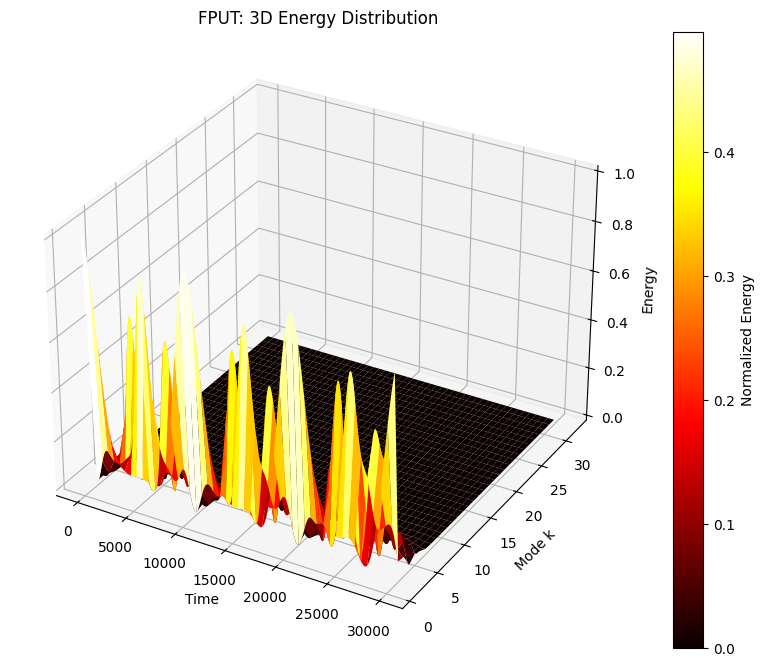

In [58]:
T, K = np.meshgrid(C_time, range(1, 33))
Z = normalized_data.T

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T, K, Z, cmap='hot', alpha=1)
ax.set_xlabel('Time')
ax.set_ylabel('Mode k')
ax.set_zlabel('Energy')
ax.set_title('FPUT: 3D Energy Distribution')
fig.colorbar(surf, label='Normalized Energy')  # Only use this line for colorbar
plt.show()

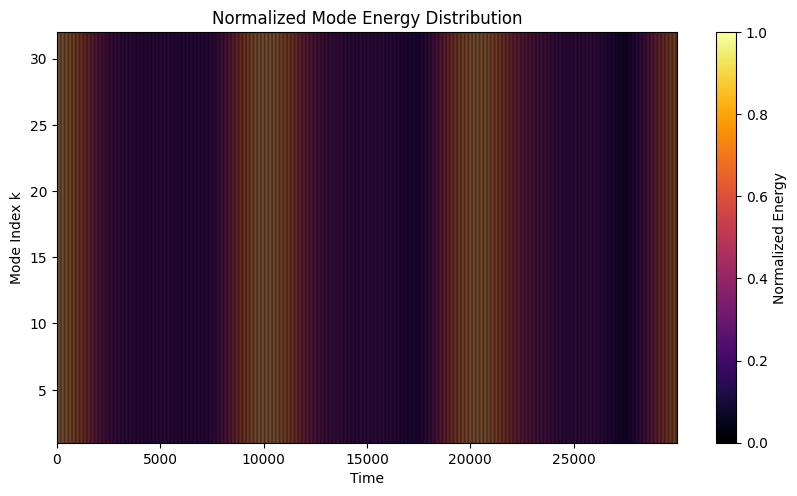

In [59]:
N = 32
# Extract normalized energy columns
normalized_data = np.array(RK_time)

# Create heatmap
plt.figure(figsize=(15/1.5, 8/1.5))
plt.imshow(normalized_data.T, aspect='auto', origin='lower',
           extent=[C_time[0], C_time[-1], 1, N],
           cmap='inferno', vmin=0, vmax=1)
plt.colorbar(label='Normalized Energy')
plt.xlabel('Time')
plt.ylabel('Mode Index k')
plt.title(f'Normalized Mode Energy Distribution')
plt.show()

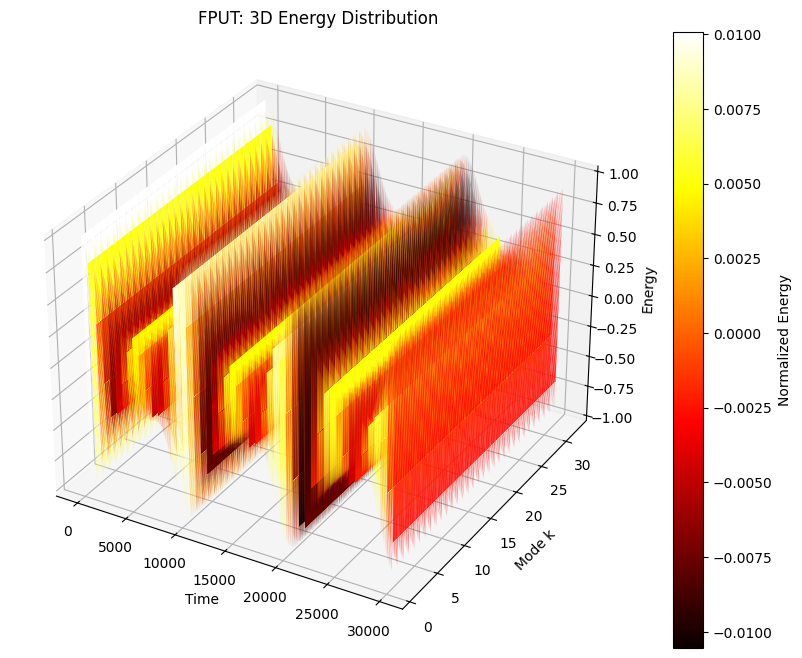

In [ ]:
T, K = np.meshgrid(C_time, range(1, 33))
Z = normalized_data.T

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T, K, Z, cmap='hot', alpha=1)
ax.set_xlabel('Time')
ax.set_ylabel('Mode k')
ax.set_zlabel('Recurance(t)')
ax.set_title('FPUT: 3D Recurance Distribution')
fig.colorbar(surf, label='Normalized Energy')  # Only use this line for colorbar
plt.show()

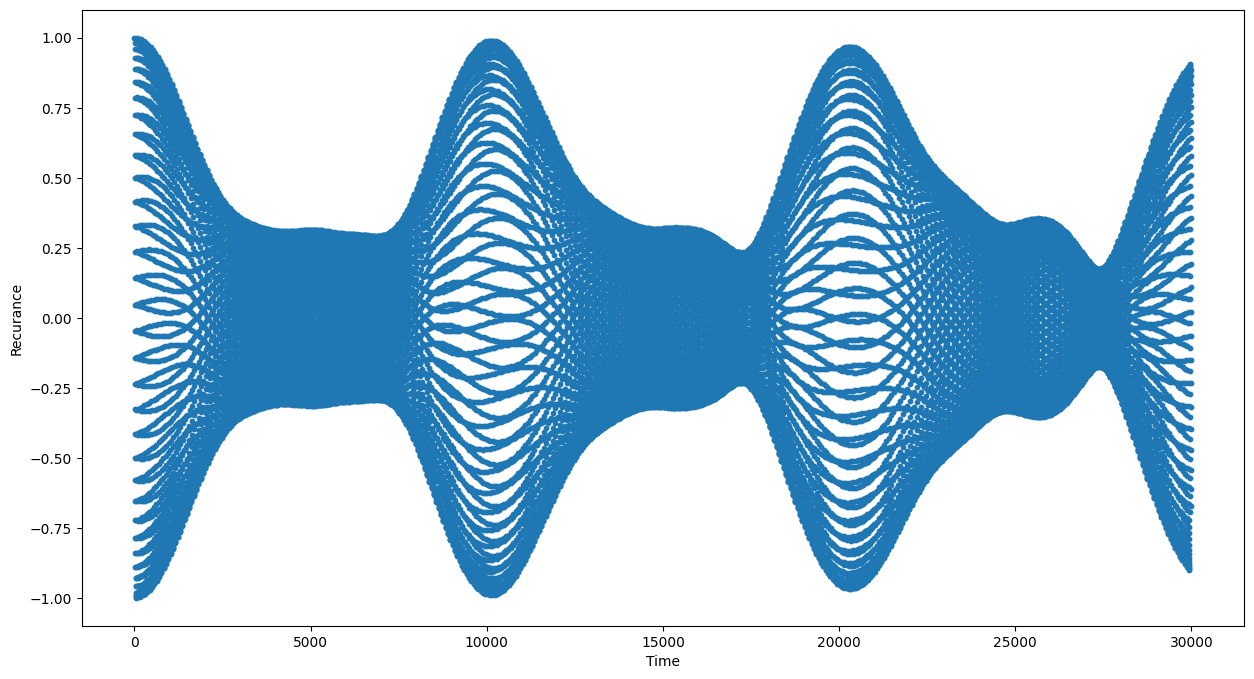

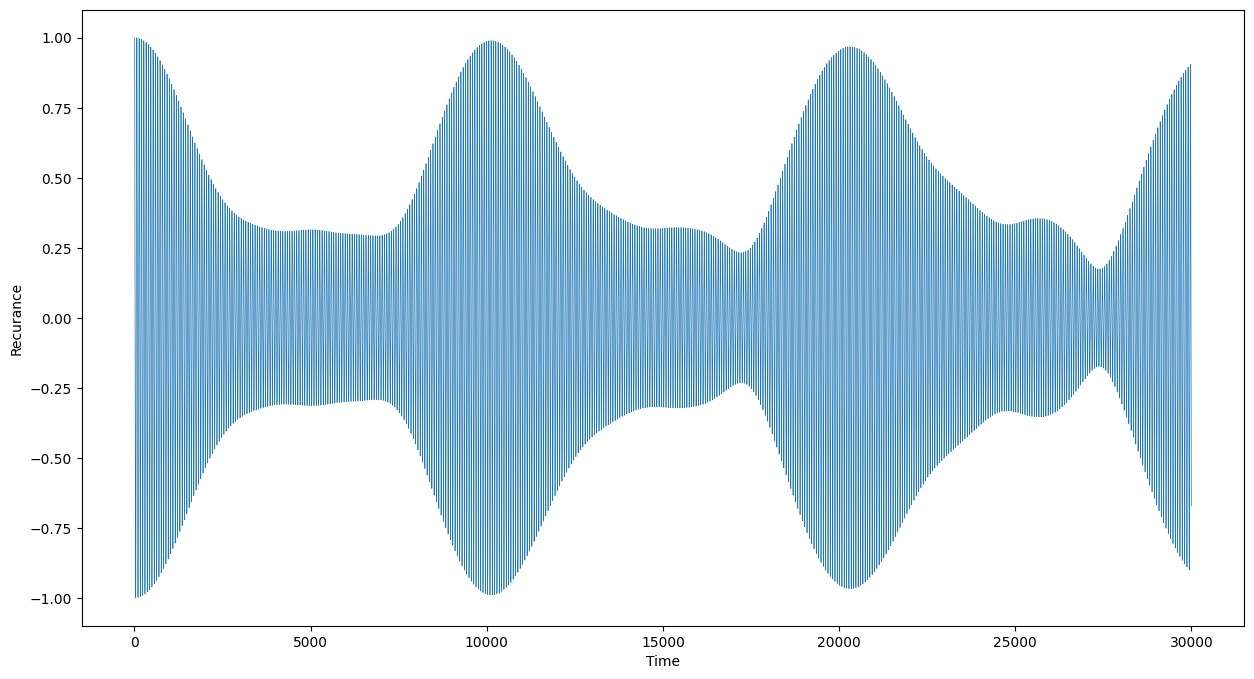

In [76]:
plt.figure(figsize=(15, 8))
plt.scatter(C_time, R_time, s = 10)
# plt.xlim(0, 15000)
plt.xlabel("Time")
plt.ylabel("Recurance")
plt.show()

plt.figure(figsize=(15, 8))
plt.plot(C_time, R_time, linewidth = 0.5)
# plt.xlim(0, 15000)

plt.xlabel("Time")
plt.ylabel("Recurance")
plt.show()